In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute  import SimpleImputer


In [75]:
df = pd.read_csv('titanic_data_updated.csv')
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

x = df.drop(['Survived'], axis=1)
y = df['Survived']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [76]:
age_imputerr = SimpleImputer(missing_values=np.nan, strategy='mean')
age_imputerr.fit(x_train[['Age']])
x_train['Age'] = age_imputerr.transform(x_train[['Age']])


In [77]:
age_imputerr = SimpleImputer(missing_values=np.nan, strategy='mean')
age_imputerr.fit(x_test[['Age']])
x_test['Age'] = age_imputerr.transform(x_test[['Age']])


In [78]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

<Axes: xlabel='Embarked', ylabel='count'>

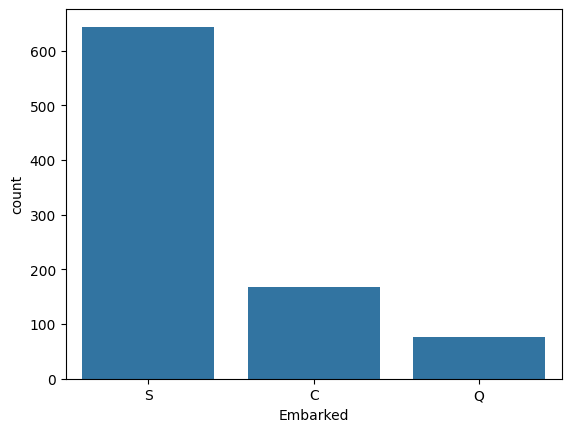

In [79]:
sns.countplot(data=df, x=df['Embarked'])

In [80]:
embarked_imputerr = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
embarked_imputerr.fit(x_train[['Embarked']])

# transform both test and train
x_train['Embarked'] = embarked_imputerr.transform(x_train[['Embarked']]).ravel()
x_test['Embarked'] = embarked_imputerr.transform(x_test[['Embarked']]).ravel()

print(x_train['Embarked'].isnull().sum())
print(x_test['Embarked'].isnull().sum())


0
0


In [81]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

<Axes: xlabel='Cabin', ylabel='count'>

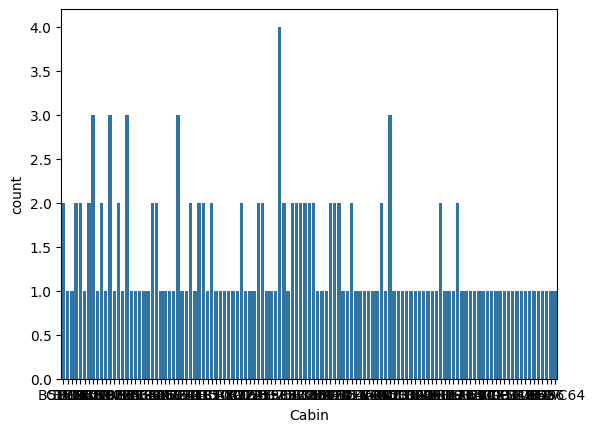

In [82]:
sns.countplot(data=x_train, x=x_train['Cabin'])

In [83]:
cabin_imputerr = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Missing', add_indicator=True)
cabin_imputerr.fit(x_train[['Cabin']])
x_train[['Cabin','Cabin_Missing_Indi']] = cabin_imputerr.transform(x_train[['Cabin']])
x_test[['Cabin', 'Cabin_Missing_Indi']] = cabin_imputerr.transform(x_test[['Cabin']])


In [84]:
x_train.isnull().sum()

Pclass                0
Sex                   0
Age                   0
SibSp                 0
Parch                 0
Fare                  0
Cabin                 0
Embarked              0
Cabin_Missing_Indi    0
dtype: int64

In [85]:
x_test.isnull().sum()

Pclass                0
Sex                   0
Age                   0
SibSp                 0
Parch                 0
Fare                  0
Cabin                 0
Embarked              0
Cabin_Missing_Indi    0
dtype: int64